# Phép chập trong hệ thống LTI

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dangquanghieu/tinhieu-hethong-notebooks/blob/main/notebooks/02_phep-chap-lti.ipynb)

Notebook minh họa phép chập (convolution) giữa tín hiệu đầu vào và đáp ứng xung (impulse response) của hệ thống tuyến tính bất biến theo thời gian (LTI): tính trên đồ thị, viết hàm tính tổng chập, kiểm chứng bằng Monte Carlo, và xấp xỉ tích phân chập bằng tổng chập.

**Mục tiêu**
- Tính $y[n_0]$ trên đồ thị theo các bước: lấy đối xứng, dịch, nhân, lấy tổng.
- Tự viết hàm tính tổng chập (convolution sum) theo định nghĩa, rồi viết lại thành hàm `conv` gọn hơn chỉ cần hai vòng lặp, và so sánh với `np.convolve` bằng thử nghiệm Monte Carlo.
- Tính tích phân chập (convolution integral) theo định nghĩa và quan sát đoạn chồng lên nhau thay đổi theo $t$.
- Xấp xỉ phép chập liên tục bằng tổng chập rời rạc nhân với chu kỳ lấy mẫu $T_s$.

**Ghi chú**: Đây là tài liệu bổ trợ cho [Bài giảng Tín hiệu và hệ thống](https://github.com/dangquanghieu/book-thht)

## Tóm tắt lý thuyết

Với hệ thống LTI có đáp ứng xung $h$, đầu ra bằng phép chập của đầu vào với đáp ứng xung:

$$
y[n] = x[n] * h[n] := \sum_{k=-\infty}^{\infty} x[k]\,h[n-k], \qquad
y(t) = x(t) * h(t) := \int_{-\infty}^{\infty} x(\tau)\,h(t-\tau)\,d\tau .
$$

Để tính $y[n_0]$ trên đồ thị: (1) vẽ $x[k]$ và $h[k]$; (2) lấy đối xứng $h[k]\to h[-k]$; (3) dịch đi $n_0$ để được $h[n_0-k]$; (4) nhân $v_{n_0}[k]=x[k]h[n_0-k]$; (5) cộng tất cả các giá trị của $v_{n_0}[k]$. Với tín hiệu liên tục, bước (5) là tích phân của $v_{t_0}(\tau)=x(\tau)h(t_0-\tau)$.

Nếu $x[n]$ khác 0 trên $n_x\le n\le n_{x'}$ và $h[n]$ khác 0 trên $n_h\le n\le n_{h'}$ thì $y[n]$ khác 0 trên $n_x+n_h\le n\le n_{x'}+n_{h'}$, tức dài $L+P-1$ mẫu nếu $x$ dài $L$ mẫu và $h$ dài $P$ mẫu.

Lấy mẫu với chu kỳ $T_s$: $x[n]=x(nT_s)$, $h[n]=h(nT_s)$. Xấp xỉ tích phân bằng tổng hình chữ nhật cho

$$
y(nT_s) \approx T_s \sum_{k} x[k]h[n-k] = T_s\,\bigl(x[n] * h[n]\bigr).
$$

Ký hiệu: $k$ là chỉ số của tổng, $\tau$ là biến của tích phân; $T_s$ có đơn vị giây.

*Xem thêm: [sách Tín hiệu và hệ thống](https://github.com/dangquanghieu/book-thht), Chương 2 (Hệ thống LTI), các mục "Đáp ứng xung và phép chập cho hệ thống rời rạc" (Cách tính phép chập rời rạc; Một số lưu ý khi tính phép chập; Tính phép chập trên Matlab) và "Đáp ứng xung và phép chập cho hệ thống liên tục" (Cách tính phép chập liên tục).*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# Cấu hình phần trình bày: màu sắc, cỡ chữ, lưới và độ phân giải.
COLORS = {
    "main": "#0072B2",
    "compare": "#D55E00",
    "extra": "#009E73",
    "reference": "#CC79A7",
}

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.color": "#D9E2EA",
    "grid.alpha": 0.8,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "lines.linewidth": 1.8,
    "axes.prop_cycle": plt.cycler(color=[
        COLORS["main"], COLORS["compare"], COLORS["extra"], COLORS["reference"]
    ]),
})

In [2]:
# Các hàm dưới đây chỉ định cách trình bày từng loại đồ thị.
def stem(ax, n, x, label=None, color=None):
    """Vẽ dãy rời rạc x[n] tại các chỉ số n đã cho."""
    if color is None:
        color = COLORS["main"]

    marker, stems, baseline = ax.stem(
        n, x, linefmt="-", markerfmt="o", basefmt="k-", label=label
    )
    plt.setp(stems, color=color, linewidth=1.5)
    plt.setp(marker, color=color, markerfacecolor=color, markersize=6)
    plt.setp(baseline, linewidth=0.8)
    ax.set_xlabel("Chỉ số thời gian $n$ (mẫu)")
    return ax

def style_continuous(ax):
    """Đặt nhãn trục cho đồ thị tín hiệu liên tục."""
    ax.set_xlabel("Thời gian $t$ (s)")
    ax.set_ylabel("Biên độ")

def style_discrete(ax):
    """Đặt nhãn biên độ cho đồ thị tín hiệu rời rạc."""
    ax.set_ylabel("Biên độ")

In [3]:
# Hàm dùng chung cho các thanh trượt: hình được vẽ vào bộ nhớ rồi gán vào một khung ảnh duy nhất.
try:
    from io import BytesIO
    from ipywidgets import Image, VBox
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

def hien_thanh_truot(slider, ham_ve):
    """Hiện thanh trượt và một khung ảnh; mỗi lần kéo chỉ thay nội dung khung ảnh."""
    anh = Image(format="png")

    def cap_nhat(change=None):
        fig = ham_ve(slider.value)
        buf = BytesIO()
        fig.savefig(buf, format="png", bbox_inches="tight")
        plt.close(fig)
        anh.value = buf.getvalue()

    slider.observe(cap_nhat, names="value")
    cap_nhat()
    display(VBox([slider, anh]))

## 1. Tính $y[n_0]$ trên đồ thị

Ví dụ lấy từ giáo trình: $x[n]=\{1,1,1,1,1\}$ tại $n=-1,\dots,3$ và $h[n]=\{1,\,0.75,\,0.5,\,0.25\}$ tại $n=0,\dots,3$.

Hàm `conv_at` tính **một** giá trị $y[n_0]$ và trả về cả $h[n_0-k]$ lẫn tích $v[k]$ để vẽ. Hình dưới có bốn hàng: $x[k]$, $h[n_0-k]$, tích $v[k]=x[k]\,h[n_0-k]$ và các giá trị $y[n]$ đã tính xong. Tổng của hàng thứ ba chính là $y[n_0]$.

In [4]:
# --- Tín hiệu đầu vào và đáp ứng xung, luôn đi kèm mảng chỉ số ---
nx = np.arange(-1, 4)                 # x[n] khác 0 tại n = -1, ..., 3
x = np.ones(len(nx))
nh = np.arange(0, 4)                  # h[n] khác 0 tại n = 0, ..., 3
h = np.array([1.0, 0.75, 0.5, 0.25])

def get_value(sig, n_sig, idx):
    # Trả về sig tại các chỉ số idx; bằng 0 ở ngoài khoảng chỉ số n_sig.
    out = np.zeros(len(idx), dtype=sig.dtype)
    inside = (idx >= n_sig[0]) & (idx <= n_sig[-1])
    out[inside] = sig[idx[inside] - n_sig[0]]
    return out

def conv_at(x, nx, h, nh, n0, k):
    # Tính y[n0] = tổng của x[k] h[n0-k] trên các chỉ số k đã cho.
    x_k = get_value(x, nx, k)             # x[k]
    h_shifted = get_value(h, nh, n0 - k)  # h[n0-k]: lấy đối xứng rồi dịch n0
    v = x_k * h_shifted                   # v[k] = x[k] h[n0-k]
    return np.sum(v), h_shifted, v

In [5]:
def plot_discrete_step(n0):
    k = np.arange(-6, 10)
    x_k = get_value(x, nx, k)
    y_n0, h_shifted, v = conv_at(x, nx, h, nh, n0, k)

    # Các giá trị y[n] đã tính xong, từ n đầu tiên của đầu ra đến n0.
    n_done = np.arange(nx[0] + nh[0], n0 + 1)
    y_done = np.zeros(len(n_done))
    for i, n in enumerate(n_done):
        y_done[i] = conv_at(x, nx, h, nh, n, k)[0]

    fig, axes = plt.subplots(4, 1, figsize=(9, 10))
    stem(axes[0], k, x_k)
    axes[0].set_title("$x[k]$")
    stem(axes[1], k, h_shifted, color=COLORS["compare"])
    axes[1].set_title(f"$h[n_0-k]$ với $n_0={n0}$")
    stem(axes[2], k, v, color=COLORS["extra"])
    axes[2].set_title(f"$v[k]=x[k]\\,h[n_0-k]$; tổng các giá trị: $y[{n0}]={y_n0:.2f}$")
    if len(n_done) > 0:
        stem(axes[3], n_done, y_done, color=COLORS["reference"])
        axes[3].plot(n0, y_n0, "o", color=COLORS["compare"], markersize=10, fillstyle="none")
    axes[3].set_title("$y[n]$ đã tính xong (vòng tròn: $y[n_0]$)")
    for ax in axes:
        style_discrete(ax)
        ax.set_xlim(-6.5, 9.5)
        ax.set_xticks(k)
    for ax in axes[:3]:
        ax.set_ylim(-0.2, 1.3)
        ax.set_xlabel("Chỉ số $k$")
    axes[3].set_ylim(-0.2, 2.9)
    fig.tight_layout()
    return fig

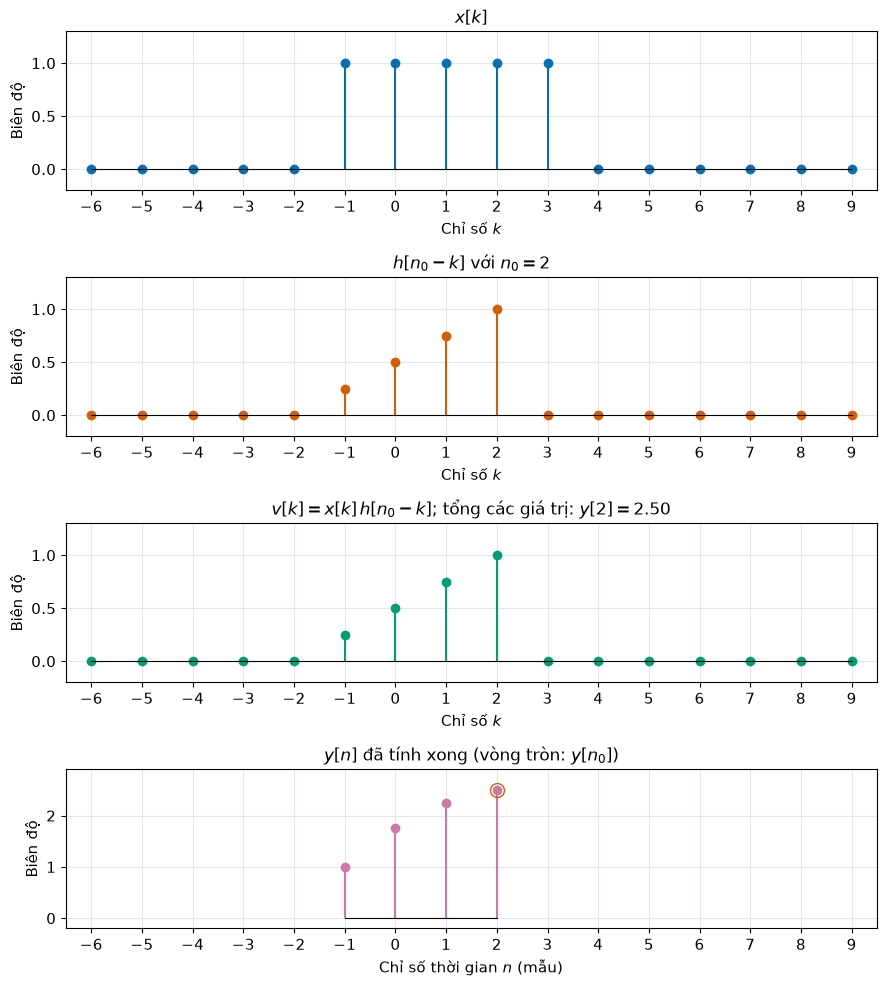

In [6]:
fig = plot_discrete_step(2)
plt.show()

**Nhận xét.** Với $n_0=2$, $h[2-k]$ khác 0 tại $k=-1,\dots,2$, đúng bằng đoạn có $x[k]\neq0$ nên hai dãy chồng khít lên nhau. Khi đó $v[k]$ gồm bốn giá trị $0.25,\,0.5,\,0.75,\,1$ và $y[2]=2.5$. Khi $n_0$ nhỏ hơn hoặc lớn hơn, phần chồng lên nhau ít đi và tổng nhỏ hơn.

Kéo thanh trượt để dịch $h[n_0-k]$ qua $x[k]$ và quan sát $y[n_0]$ được xây dựng dần ở hàng cuối.

In [7]:
if HAS_WIDGETS:
    from ipywidgets import IntSlider
    hien_thanh_truot(IntSlider(value=2, min=-2, max=7, step=1, description="$n_0$"),
                     plot_discrete_step)
else:
    print("Chưa cài ipywidgets — xem hình tĩnh ở trên.")

## 2. Hàm tính tổng chập theo định nghĩa

Tính lần lượt $y[n_0]$ cho mọi $n_0$ trong đoạn $n_x+n_h\le n_0\le n_{x'}+n_{h'}$. Hàm `conv_sum` dưới đây trả về cả giá trị $y$ và mảng chỉ số $n_y$ tương ứng. Hàm `np.convolve` chỉ trả về giá trị, nên ta phải tự dựng lại trục chỉ số bắt đầu từ $n_x+n_h$.

In [8]:
def conv_sum(x, nx, h, nh):
    # Tổng chập y[n] = tổng của x[k] h[n-k]; trả về y và chỉ số ny tương ứng.
    ny = np.arange(nx[0] + nh[0], nx[-1] + nh[-1] + 1)   # chỉ số của đầu ra
    y = np.zeros(len(ny), dtype=np.result_type(x, h))
    for i, n0 in enumerate(ny):
        y[i] = conv_at(x, nx, h, nh, n0, nx)[0]            # cộng trên k thuộc nx
    return y, ny

Chỉ số n : [-1  0  1  2  3  4  5  6]
y[n]     : [1.   1.75 2.25 2.5  2.5  1.5  0.75 0.25]


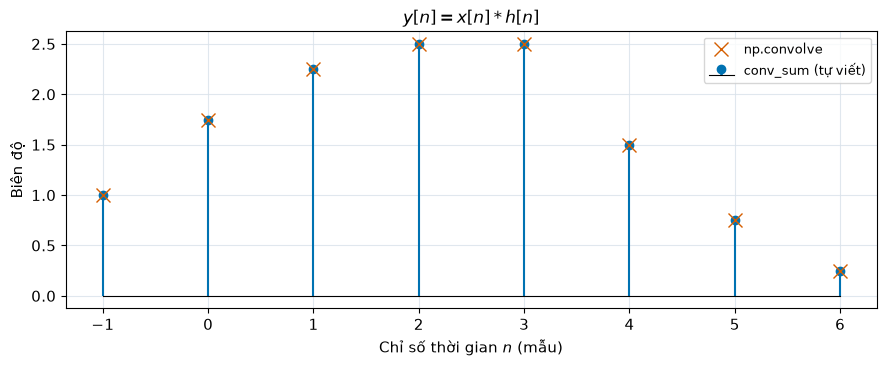

In [9]:
# --- Tính bằng hàm tự viết và bằng np.convolve ---
y_mine, ny_mine = conv_sum(x, nx, h, nh)
y_np = np.convolve(x, h)
ny_np = np.arange(nx[0] + nh[0], nx[0] + nh[0] + len(y_np))  # np.convolve không trả về chỉ số

assert np.array_equal(ny_mine, ny_np)
assert np.allclose(y_mine, y_np)
print("Chỉ số n :", ny_mine)
print("y[n]     :", y_mine)

# --- Vẽ kết quả ---
fig, ax = plt.subplots(figsize=(9, 3.8))
stem(ax, ny_mine, y_mine, label="conv_sum (tự viết)")
ax.plot(ny_np, y_np, "x", color=COLORS["compare"], markersize=10, label="np.convolve")
style_discrete(ax)
ax.set_xticks(ny_mine)
ax.set_title("$y[n]=x[n]*h[n]$")
ax.legend()
fig.tight_layout()
plt.show()

**Nhận xét.** $y[n]$ có 8 mẫu $(5+4-1)$, bắt đầu tại $n=-1+0=-1$ và kết thúc tại $n=3+3=6$. Dấu $\times$ của `np.convolve` trùng với các mẫu của hàm tự viết, với điều kiện trục chỉ số được dựng đúng.

## 3. Hàm `conv` hiệu quả hơn

`conv_sum` làm đúng theo định nghĩa nhưng chưa gọn: với mỗi $n_0$ nó phải lấy đối xứng, dịch và đệm số 0 cho cả hai dãy. Ta có thể bỏ trục thời gian khỏi tham số nhờ tính chất dịch của phép chập: nếu $x[n]$ bắt đầu tại $n_x$ và $h[n]$ bắt đầu tại $n_h$ thì $y[n]$ bắt đầu tại $n_x+n_h$. Do đó có thể coi cả hai dãy bắt đầu tại chỉ số mảng $0$, tính phép chập của hai mảng, rồi cộng độ dịch $n_x+n_h$ vào trục thời gian của kết quả.

Với chỉ số mảng $i=0,\dots,L-1$ của $x$ và $j=0,\dots,P-1$ của $h$, mỗi tích $x[i]\,h[j]$ đóng góp vào đúng một mẫu của đầu ra, đó là $y[i+j]$:

$$
y[i+j] \mathrel{+}= x[i]\,h[j].
$$

Hai vòng lặp lồng nhau (một vòng theo $i$, một vòng theo $j$) là đủ. Chỉ cần $L\cdot P$ phép nhân, không cần đệm số 0 hay lấy đối xứng.

In [10]:
def conv(x, h):
    # Phép chập của hai mảng, coi cả hai dãy bắt đầu tại chỉ số mảng 0.
    y = np.zeros(len(x) + len(h) - 1, dtype=np.result_type(x, h))
    for i in range(len(x)):
        for j in range(len(h)):
            y[i + j] += x[i] * h[j]    # tích x[i] h[j] đóng góp vào y[i+j]
    return y

In [11]:
# --- Kiểm tra trên ví dụ ở mục 1; độ dịch của đầu ra là nx[0] + nh[0] ---
y_fast = conv(x, h)
ny_fast = nx[0] + nh[0] + np.arange(len(y_fast))

assert np.allclose(y_fast, y_mine)
assert np.array_equal(ny_fast, ny_mine)
print("conv(x, h):", y_fast)
print("Chỉ số n  :", ny_fast)

conv(x, h): [1.   1.75 2.25 2.5  2.5  1.5  0.75 0.25]
Chỉ số n  : [-1  0  1  2  3  4  5  6]


**Nhận xét.** `conv` cho cùng kết quả với `conv_sum`. Trục thời gian không còn nằm trong hàm: ta dựng lại ở bên ngoài bằng $n_y=n_x+n_h+i$, với $i$ là chỉ số mảng của đầu ra.

## 4. Kiểm chứng bằng Monte Carlo

Một ví dụ chưa đủ để tin hàm đúng. Ta chạy 1000 lần thử với độ dài và giá trị của $x$, $h$ chọn ngẫu nhiên, rồi so sánh `conv` với `np.convolve`. Vì cả hai hàm đều coi dãy bắt đầu tại chỉ số mảng 0, chỉ cần so sánh các giá trị. Dùng `rng = np.random.default_rng(<seed>)` để kết quả lặp lại được.

Số lần thử: 1000, tất cả đều khớp (np.allclose).
Sai số tuyệt đối lớn nhất trên mọi lần thử: 3.55e-15


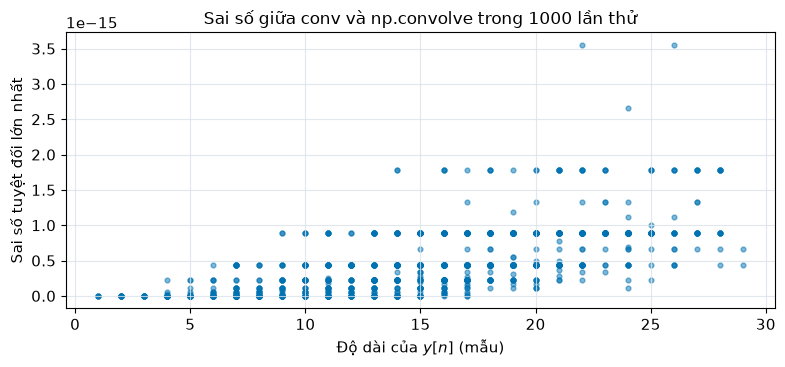

In [12]:
rng = np.random.default_rng(2025)
num_trials = 1000
max_errors = np.zeros(num_trials)
out_lengths = np.zeros(num_trials, dtype=int)

for trial in range(num_trials):
    # --- Tạo ngẫu nhiên hai dãy ---
    Lx = rng.integers(1, 16)
    Lh = rng.integers(1, 16)
    x_r = rng.standard_normal(Lx)
    h_r = rng.standard_normal(Lh)

    # --- Tính bằng hai cách ---
    y_a = conv(x_r, h_r)
    y_b = np.convolve(x_r, h_r)

    # --- So sánh giá trị ---
    assert len(y_a) == Lx + Lh - 1
    assert np.allclose(y_a, y_b)
    max_errors[trial] = np.max(np.abs(y_a - y_b))
    out_lengths[trial] = len(y_a)

print(f"Số lần thử: {num_trials}, tất cả đều khớp (np.allclose).")
print(f"Sai số tuyệt đối lớn nhất trên mọi lần thử: {max_errors.max():.2e}")

# --- Vẽ phân bố sai số ---
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.scatter(out_lengths, max_errors, s=12, alpha=0.5, color=COLORS["main"])
ax.set_xlabel("Độ dài của $y[n]$ (mẫu)")
ax.set_ylabel("Sai số tuyệt đối lớn nhất")
ax.set_title("Sai số giữa conv và np.convolve trong 1000 lần thử")
fig.tight_layout()
plt.show()

**Nhận xét.** Cả 1000 lần thử đều khớp về độ dài và giá trị. Sai số tuyệt đối lớn nhất chỉ cỡ $10^{-15}$ (sai số làm tròn số thực), và có xu hướng lớn hơn khi $y[n]$ dài hơn vì mỗi giá trị cộng nhiều số hạng hơn. Vì thế so sánh phải dùng `np.allclose` thay cho `==`.

## 5. Tích phân chập theo định nghĩa

Ví dụ lấy từ giáo trình: mạch RC nối tiếp với $RC=1$ s, đầu vào là xung chữ nhật (rectangular pulse) $x(t)=u(t)-u(t-2)$, đáp ứng xung $h(t)=e^{-t}u(t)$. Lời giải giải tích gồm ba đoạn:

$$
y(t)=\begin{cases}
0, & t<0,\\
1-e^{-t}, & 0\le t<2,\\
(e^{2}-1)\,e^{-t}, & t\ge2.
\end{cases}
$$

Máy tính không lấy tích phân vô hạn được, nên ta lấy lưới $\tau$ mịn (bước $0.002$ s) và tính $y(t_0)=\int x(\tau)\,h(t_0-\tau)\,d\tau$ bằng quy tắc hình thang (trapezoidal rule). Từng bước vẫn như trường hợp rời rạc: lấy đối xứng, dịch $t_0$, nhân, rồi lấy tích phân.

In [13]:
# --- Tín hiệu liên tục (quy ước u(0) = 1) ---
def x_cont(t):
    return ((t >= 0) & (t < 2)).astype(float)    # u(t) - u(t-2)

def h_cont(t):
    return np.exp(-t) * (t >= 0)                 # e^{-t} u(t)

def y_exact(t):
    # Lời giải giải tích theo ba đoạn của t.
    y = np.zeros_like(t)
    seg1 = (t >= 0) & (t < 2)
    seg2 = t >= 2
    y[seg1] = 1 - np.exp(-t[seg1])
    y[seg2] = (np.exp(2) - 1) * np.exp(-t[seg2])
    return y

# --- Lưới của biến tích phân tau ---
dtau = 0.002
tau = np.arange(-3, 8, dtau)

def conv_integral_at(t0):
    # Tính y(t0) = tích phân của x(tau) h(t0 - tau) theo tau.
    v = x_cont(tau) * h_cont(t0 - tau)    # h(t0 - tau): lấy đối xứng rồi dịch t0
    return trapezoid(v, tau), v

# --- Kiểm chứng tại một số giá trị t0 ---
t_check = np.array([-0.5, 0.5, 1.2, 2.0, 3.5, 5.0])
y_num = np.array([conv_integral_at(t0)[0] for t0 in t_check])
assert np.allclose(y_num, y_exact(t_check), atol=5e-3)
print("t0     :", t_check)
print("số     :", np.round(y_num, 4))
print("giải tích:", np.round(y_exact(t_check), 4))

t0     : [-0.5  0.5  1.2  2.   3.5  5. ]
số     : [0.     0.3939 0.6995 0.8655 0.1931 0.0431]
giải tích: [0.     0.3935 0.6988 0.8647 0.1929 0.043 ]


In [14]:
def plot_continuous_step(t0):
    y_t0, v = conv_integral_at(t0)
    t_done = np.arange(-3, t0, 0.01)

    fig, axes = plt.subplots(4, 1, figsize=(9, 10))
    axes[0].plot(tau, x_cont(tau))
    axes[0].set_title(r"$x(\tau)$")
    axes[1].plot(tau, h_cont(t0 - tau), color=COLORS["compare"])
    axes[1].set_title(rf"$h(t_0-\tau)$ với $t_0={t0:.1f}$")
    axes[2].plot(tau, v, color=COLORS["extra"])
    axes[2].fill_between(tau, v, color=COLORS["extra"], alpha=0.3)
    axes[2].set_title(rf"$v(\tau)=x(\tau)\,h(t_0-\tau)$; diện tích: $y({t0:.1f})={y_t0:.3f}$")
    axes[3].plot(t_done, y_exact(t_done), color=COLORS["reference"])
    axes[3].plot(t0, y_t0, "o", color=COLORS["compare"], markersize=9)
    axes[3].set_title("$y(t)$ đã tính xong (chấm: $y(t_0)$)")
    for ax in axes:
        style_continuous(ax)
        ax.set_xlim(-3, 7)
        ax.set_ylim(-0.1, 1.3)
    axes[0].set_xlabel(r"$\tau$ (s)")
    axes[1].set_xlabel(r"$\tau$ (s)")
    axes[2].set_xlabel(r"$\tau$ (s)")
    fig.tight_layout()
    return fig

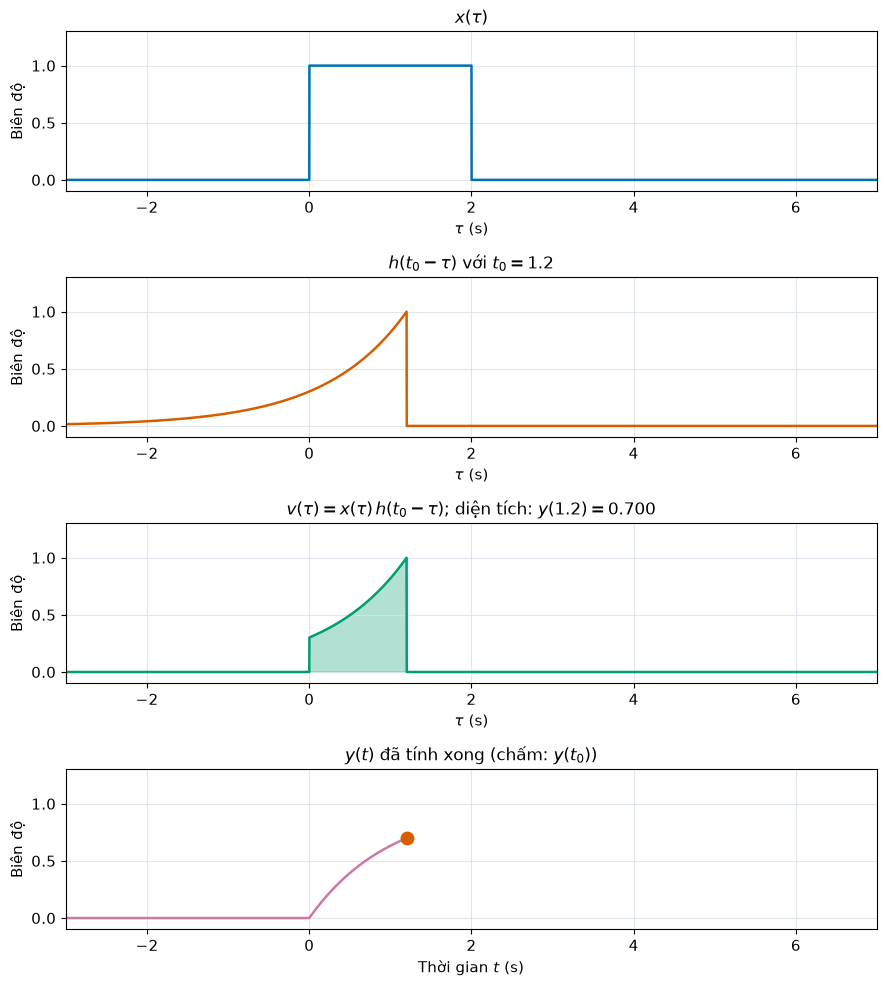

In [15]:
fig = plot_continuous_step(1.2)
plt.show()

**Nhận xét.** Với $t_0=1.2$, $h(t_0-\tau)$ là hàm mũ bị cắt tại $\tau=1.2$, nên phần chồng lên nhau với $x(\tau)$ chỉ là đoạn $0\le\tau\le1.2$. Diện tích dưới $v(\tau)$ là $y(1.2)\approx0.700$, khớp với $1-e^{-1.2}\approx0.699$. Khi $t_0<0$ không có phần chồng nên $y=0$; khi $t_0>2$ toàn bộ xung chữ nhật nằm trong vùng chồng và $y(t)$ giảm dần theo $e^{-t}$. Đường $y(t)$ tính theo định nghĩa trùng với lời giải giải tích, sai số lớn nhất cỡ $10^{-3}$ do bước lưới $\tau$ hữu hạn.

Kéo thanh trượt $t_0$ để quan sát đoạn chồng lên nhau và diện tích dưới $v(\tau)$ thay đổi.

In [16]:
if HAS_WIDGETS:
    from ipywidgets import FloatSlider
    hien_thanh_truot(FloatSlider(value=1.2, min=-1, max=6, step=0.1, description="$t_0$"),
                     plot_continuous_step)
else:
    print("Chưa cài ipywidgets — xem hình tĩnh ở trên.")

Lặp lại phép tính cho nhiều giá trị $t_0$ sẽ dựng được cả đường $y(t)$ theo định nghĩa.

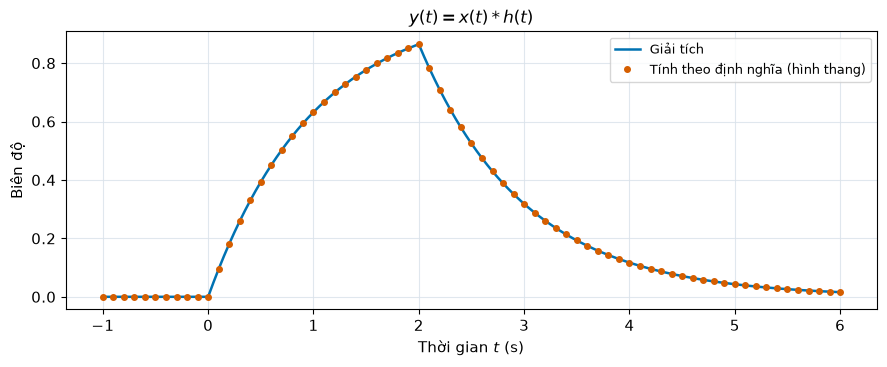

Sai số lớn nhất so với giải tích: 8.65e-04


In [17]:
# --- Tính y(t) theo định nghĩa tại từng t0 ---
t_grid = np.arange(-1, 6.001, 0.1)
y_by_definition = np.zeros(len(t_grid))
for i, t0 in enumerate(t_grid):
    y_by_definition[i] = conv_integral_at(t0)[0]

# --- Vẽ so sánh với lời giải giải tích ---
t_fine = np.arange(-1, 6.001, 0.01)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(t_fine, y_exact(t_fine), label="Giải tích")
ax.plot(t_grid, y_by_definition, "o", color=COLORS["compare"], markersize=4,
        label="Tính theo định nghĩa (hình thang)")
style_continuous(ax)
ax.set_title("$y(t)=x(t)*h(t)$")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Sai số lớn nhất so với giải tích: {np.max(np.abs(y_by_definition - y_exact(t_grid))):.2e}")

## 6. Dùng tổng chập để tính chập liên tục

Lấy mẫu $x(t)$ và $h(t)$ với chu kỳ $T_s$ rồi dùng hàm `conv`. Vì tổng chập chỉ cộng các giá trị mẫu mà không có bề rộng $d\tau$, ta phải nhân kết quả với $T_s$:

$$
y(nT_s)\approx T_s\,\bigl(x[n]*h[n]\bigr), \qquad x[n]=x(nT_s),\; h[n]=h(nT_s).
$$

Cả $x(t)$ và $h(t)$ đều bắt đầu tại $t=0$ nên đầu ra cũng bắt đầu tại $t=0$, và mẫu thứ $i$ của `conv` ứng với $t=iT_s$. Đáp ứng xung $e^{-t}u(t)$ kéo dài vô hạn nên ta cắt tại $8$ s (khi đó $e^{-8}\approx3\times10^{-4}$). Việc cắt chỉ ảnh hưởng đến $y(t)$ ở $t>8$ s, nên ta chỉ xét $t\le6$ s.

In [18]:
def approx_conv(Ts, t_h=8.0):
    # Xấp xỉ y(t) = x(t) * h(t) bằng Ts nhân với tổng chập của các mẫu.
    n_x = np.arange(0, round(2 / Ts))                 # x(t) khác 0 trên 0 <= t < 2
    x_s = x_cont(n_x * Ts)                            # x[n] = x(n Ts)
    n_h = np.arange(0, round(t_h / Ts) + 1)           # h(t) cắt tại t_h
    h_s = h_cont(n_h * Ts)                            # h[n] = h(n Ts)
    y_s = conv(x_s, h_s)
    t_y = np.arange(len(y_s)) * Ts                    # cả hai dãy bắt đầu tại 0
    keep = t_y <= 6                                   # chỉ giữ t <= 6 s
    return t_y[keep], Ts * y_s[keep]

In [19]:
def plot_approx(ax, Ts):
    t_s, y_s = approx_conv(Ts)
    t_fine = np.arange(0, 6.001, 0.01)
    err = np.max(np.abs(y_s - y_exact(t_s)))
    ax.plot(t_fine, y_exact(t_fine), label="Giải tích")
    ax.plot(t_s, y_s, "o", color=COLORS["compare"], markersize=4,
            label=r"$T_s\,(x[n]*h[n])$")
    style_continuous(ax)
    ax.set_title(f"$T_s={Ts}$ s; sai số lớn nhất = {err:.3f}")
    ax.legend()

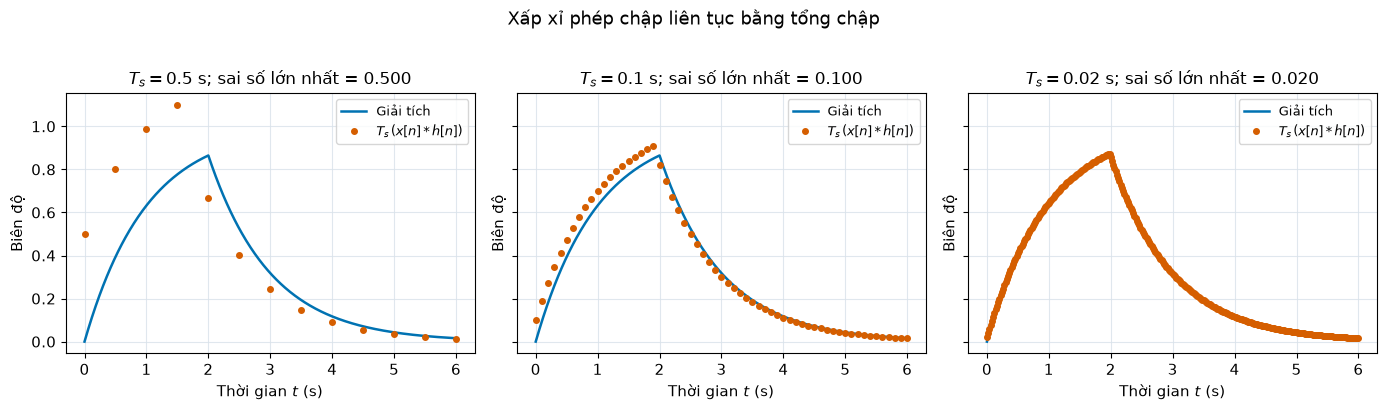

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, Ts in zip(axes, [0.5, 0.1, 0.02]):
    plot_approx(ax, Ts)
fig.suptitle("Xấp xỉ phép chập liên tục bằng tổng chập", y=1.02)
fig.tight_layout()
plt.show()

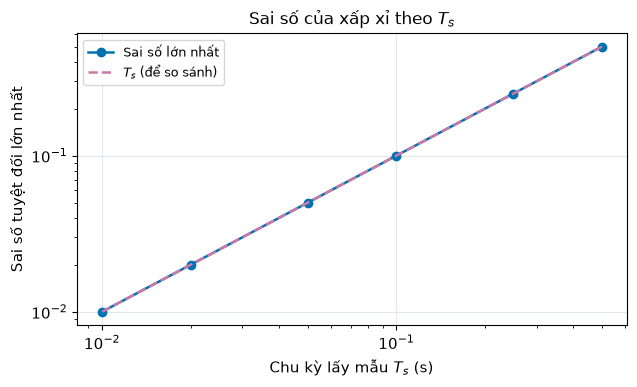

Ts =  0.50 s   sai số = 0.5000
Ts =  0.25 s   sai số = 0.2500
Ts =  0.10 s   sai số = 0.1000
Ts =  0.05 s   sai số = 0.0500
Ts =  0.02 s   sai số = 0.0200
Ts =  0.01 s   sai số = 0.0100


In [21]:
# --- Sai số giảm theo Ts ---
Ts_values = [0.5, 0.25, 0.1, 0.05, 0.02, 0.01]
errors = np.zeros(len(Ts_values))
for i, Ts in enumerate(Ts_values):
    t_s, y_s = approx_conv(Ts)
    errors[i] = np.max(np.abs(y_s - y_exact(t_s)))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.loglog(Ts_values, errors, "o-", label="Sai số lớn nhất")
ax.loglog(Ts_values, np.array(Ts_values), "--", color=COLORS["reference"],
          label=r"$T_s$ (để so sánh)")
ax.set_xlabel("Chu kỳ lấy mẫu $T_s$ (s)")
ax.set_ylabel("Sai số tuyệt đối lớn nhất")
ax.set_title("Sai số của xấp xỉ theo $T_s$")
ax.legend()
fig.tight_layout()
plt.show()
for Ts, e in zip(Ts_values, errors):
    print(f"Ts = {Ts:5.2f} s   sai số = {e:.4f}")

**Nhận xét.** Khi $T_s$ giảm, các chấm tiến sát đường giải tích. Sai số lớn nhất đúng bằng $T_s$ và giảm tỷ lệ thuận với $T_s$ (đường thẳng song song với $T_s$ trên đồ thị log-log). Sai số lớn nhất nằm tại $t=0$: giá trị đúng là $y(0)=0$ nhưng tổng chập gồm mẫu $x[0]\,h[0]$ nên cho $T_s$. Xấp xỉ vì thế cao hơn đường giải tích ở đoạn $0\le t\le2$; phần cắt $h(t)$ tại $8$ s không ảnh hưởng vì ta chỉ xét $t\le6$ s.

Chọn $T_s$ bằng thanh trượt để so sánh trực tiếp với lời giải giải tích.

In [22]:
def plot_approx_single(Ts):
    fig, ax = plt.subplots(figsize=(9, 4))
    plot_approx(ax, Ts)
    fig.tight_layout()
    return fig

if HAS_WIDGETS:
    from ipywidgets import SelectionSlider
    hien_thanh_truot(SelectionSlider(options=[0.5, 0.25, 0.1, 0.05, 0.02, 0.01], value=0.1,
                                     description="$T_s$"),
                     plot_approx_single)
else:
    print("Chưa cài ipywidgets — xem hình tĩnh ở trên.")

## Câu hỏi suy ngẫm

1. Vì sao khi tính $y[n_0]$ phải lấy đối xứng $h[k]$ trước rồi mới dịch đi $n_0$? Điều gì xảy ra nếu chỉ dịch mà không lấy đối xứng?
2. Nếu $x[n]$ bắt đầu tại $n=-3$ và dài $6$ mẫu, $h[n]$ bắt đầu tại $n=2$ và dài $4$ mẫu, thì $y[n]$ bắt đầu và kết thúc ở đâu, dài bao nhiêu mẫu?
3. Sai số giữa `conv_sum` và `np.convolve` cỡ $10^{-16}$ chứ không bằng 0. Vì sao nên dùng `np.allclose` thay cho so sánh bằng `==`?
4. Nếu quên nhân với $T_s$, biên độ của kết quả sai lệch bao nhiêu lần? Vì sao $T_s$ chính là phần bề rộng $d\tau$ của tích phân?
5. Sai số xấp xỉ giảm theo $T_s$ như thế nào? Gợi ý: tại điểm nhảy của xung chữ nhật, mẫu đầu được tính trọn vẹn thay vì một nửa; thử nêu cách hiệu chỉnh theo quy tắc hình thang.